In [2]:
import tensorflow as tf

In [3]:
import torch

In [4]:
torch.cuda.is_available()

False

In [5]:
from tensorflow.keras.datasets import fashion_mnist

# Load the Fashion MNIST dataset
fmnist = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
(X_train, y_train), (X_test, y_test) = fmnist

In [9]:
X_train.shape

(60000, 28, 28)

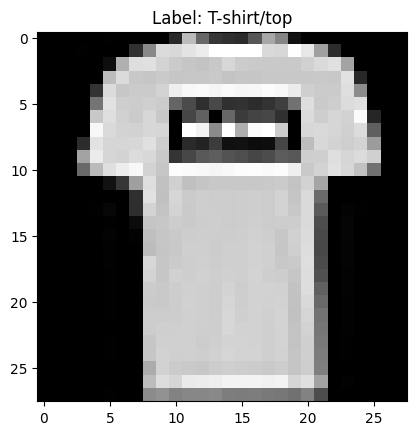

In [20]:

# i = input("Enter an index between 0 and 59999 to view a training image: ")
# i = int(i)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
i = 1

plt.imshow(X_train[i], cmap='gray')
plt.title(f"Label: {class_names[y_train[i]]}")
plt.show()

In [22]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [23]:
X_train.dtype

dtype('float64')

In [25]:
# First method: Sequential API

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, InputLayer


In [30]:
tf.random.set_seed(42)  # For reproducibility
model = Sequential()
model.add(InputLayer(input_shape=(28, 28)))
model.add(Flatten(name='flatten'))  # Flatten the 28x28 images into 784-dimensional vectors
model.add(Dense(300, activation='relu', name='hidden_layer_1'))  # Hidden layer with 300 neurons
model.add(Dense(100, activation='relu', name='hidden_layer_2'))  # Hidden layer with 100 neurons
model.add(Dense(10, activation='softmax', name='output_layer'))  # Output layer for 10 classes

c:\Users\Mezon\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [27]:
f = Flatten()

In [28]:
out = f(X_train)  # Flatten the first image in the training set

In [29]:
out.shape

TensorShape([60000, 784])

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=hidden_layer_1, built=True>,
 <Dense name=hidden_layer_2, built=True>,
 <Dense name=output_layer, built=True>]

In [36]:
weights, biases = model.get_layer('hidden_layer_1').get_weights()

In [38]:
weights.shape, biases.shape

((784, 300), (300,))

In [39]:
weights

array([[ 0.06150113, -0.01349771,  0.01909468, ...,  0.04517399,
         0.05733143,  0.04369137],
       [-0.04768848, -0.02329482, -0.0367164 , ...,  0.05465096,
        -0.00884745,  0.04090831],
       [-0.02852662, -0.03414721,  0.04646198, ...,  0.05560647,
        -0.0159969 , -0.00814884],
       ...,
       [-0.03740479, -0.04982902, -0.06507626, ...,  0.02584467,
        -0.04853967, -0.00039673],
       [ 0.06427905,  0.02175862,  0.02796096, ...,  0.04612523,
         0.03639703, -0.0275846 ],
       [-0.03084597, -0.0235732 ,  0.04133477, ...,  0.02746574,
        -0.00807622, -0.05853057]], shape=(784, 300), dtype=float32)

In [65]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [66]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [67]:
tf.keras.utils.to_categorical(y_train, num_classes=10)

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 10))

In [69]:
model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8755 - loss: 0.3367 - val_accuracy: 0.8658 - val_loss: 0.3629
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8857 - loss: 0.3087 - val_accuracy: 0.8670 - val_loss: 0.3586
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8925 - loss: 0.2887 - val_accuracy: 0.8667 - val_loss: 0.3594
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8979 - loss: 0.2715 - val_accuracy: 0.8627 - val_loss: 0.3707
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9022 - loss: 0.2612 - val_accuracy: 0.8696 - val_loss: 0.3563
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9079 - loss: 0.2453 - val_accuracy: 0.8752 - val_loss: 0.3540
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9101 - loss: 0.2364 - val_accuracy: 0.8690 - val_loss: 0.3669
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9139 - loss: 0.

In [70]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8828 - loss: 0.6073


[0.6072753071784973, 0.8827999830245972]

In [71]:
y_pred = model.predict(X_test).argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [72]:
y_test

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,), dtype=uint8)

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

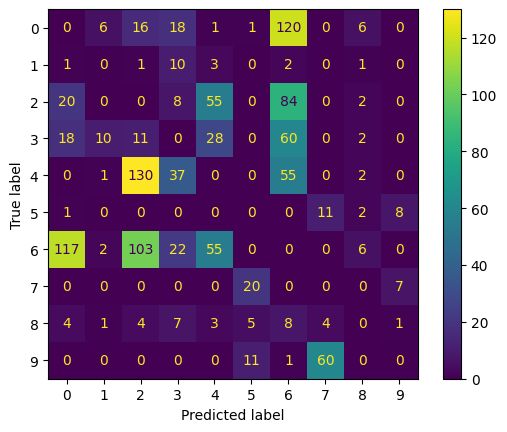

In [ ]:
cm = confusion_matrix(y_test, y_pred, sample_weight= y_pred != y_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()